In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense

# Load dataset
df = pd.read_csv('AirQuality_Dataset.csv')

# Replace -200 (missing values in this dataset)
df = df.replace(-200, np.nan)

# Drop unnecessary columns
df = df.drop(columns=['Date','Time','Unnamed: 15','Unnamed: 16'])

# Columns to fill
col_med = ['CO(GT)','NMHC(GT)','C6H6(GT)', 'NOx(GT)','T', 'RH', 'AH']
col_mean = ['PT08.S1(CO)','PT08.S2(NMHC)','PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

# Fill missing values
for col in col_med:
    df[col] = df[col].fillna(df[col].median())

for col in col_mean:
    df[col] = df[col].fillna(df[col].mean())

# Separate features and target
X = df.drop('CO(GT)', axis=1)
y = df['CO(GT)']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure column lists match existing features
col_med = [c for c in col_med if c in X_train.columns]
col_mean = [c for c in col_mean if c in X_train.columns]

# Initialize scalers
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

# Scale training data
X_train_std = scaler_std.fit_transform(X_train[col_med])
X_train_mm  = scaler_mm.fit_transform(X_train[col_mean])

# Scale testing data
X_test_std = scaler_std.transform(X_test[col_med])
X_test_mm  = scaler_mm.transform(X_test[col_mean])

# Combine scaled features
X_train_scaled = np.concatenate([X_train_std, X_train_mm], axis=1)
X_test_scaled  = np.concatenate([X_test_std, X_test_mm], axis=1)

print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)

# -------------------------------
# Scale TARGET VARIABLE (important)
# -------------------------------

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1,1))

# -------------------------------
# Defining ANN
# -------------------------------

model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='linear'))

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -------------------------------
# Training
# -------------------------------
history = model.fit( X_train_scaled, y_train_scaled,validation_split=0.2,epochs=100,batch_size=16,verbose=1)
# -------------------------------
# Evaluate model
# -------------------------------
loss, mae = model.evaluate(X_test_scaled, y_test_scaled)

print("Test MSE:", loss)
print("Test MAE:", mae)

# -------------------------------
# Predictions
# -------------------------------

y_pred_scaled = model.predict(X_test_scaled)

# Convert predictions back to original scale
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Compare predictions
comparison = pd.DataFrame({
    "Actual CO": y_test.values,
    "Predicted CO": y_pred.flatten()
})

print(comparison.head(10))

Training features shape: (7576, 12)
Testing features shape: (1895, 12)
Epoch 1/100


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2553 - mae: 0.3468 - val_loss: 0.1891 - val_mae: 0.3069
Epoch 2/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1806 - mae: 0.2929 - val_loss: 0.1748 - val_mae: 0.2966
Epoch 3/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1679 - mae: 0.2837 - val_loss: 0.1773 - val_mae: 0.2947
Epoch 4/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1611 - mae: 0.2769 - val_loss: 0.1605 - val_mae: 0.2735
Epoch 5/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1569 - mae: 0.2707 - val_loss: 0.1605 - val_mae: 0.2743
Epoch 6/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1530 - mae: 0.2666 - val_loss: 0.1775 - val_mae: 0.2896
Epoch 7/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1491 - mae: 0.2618 - val_loss: 0.1627 - val_mae: 0.2780
Epoch 8/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1471 - mae: 0.2610 - val_loss: 0.1561 - val_mae: 0.2759
Epoch 9/100
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss:

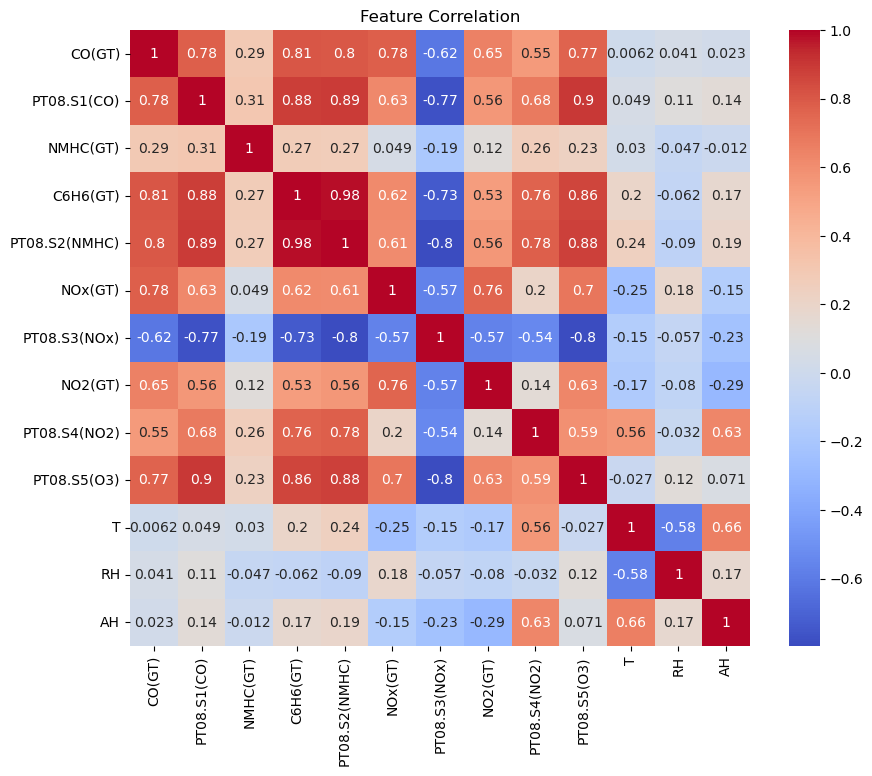

In [12]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

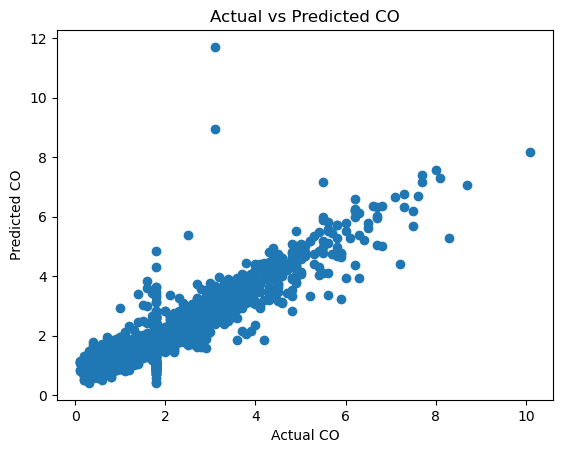

In [13]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Actual vs Predicted CO")

plt.show()

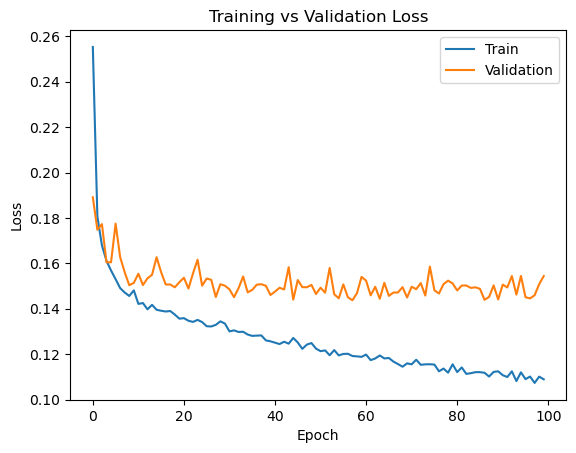

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()